# 【解答編】2026年8月5日 2026機械学習PJ 第1回 機械学習の概要 演習ノートブック

本ノートブックでは，演習を通して以下の内容を理解することを目的とする:
1. モデルでの処理の流れがどうなっているのか
2. モデルの精度を大きく左右するパラメータを変更することによる影響はどうか
3. モデルの種類を変えることによりどういう変化があるか

作成者: 坪井 一馬

## 0. 共通準備

このノートブックの実行にあたって，必ず最初に実行しておくこと．途中で「ランタイムが切断」されるなどあれば，再度実行すること．

### 0.1. モジュールのインポートなど

必要となるpythonの機能を使えるようにする．

In [ ]:
# Python標準ライブラリ
import copy
import random

# 数値計算・表形式データ・可視化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Digitsデータセットとデータ分割
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 前処理とロジスティック回帰
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 評価指標
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# 発展編で使用するPyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# 実行ごとのばらつきを小さくするため，乱数を固定する
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# GPUが使える場合はGPU，使えない場合はCPUを使用する．
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用するデバイス:", device)

使用するデバイス: cpu


### 0.2. Digitsデータセットの読み込みと確認．

Digitsデータセットには，8×8ピクセルの手書き数字画像が1797枚含まれている．

- 1枚の画像：8×8 = 64個の画素値
- 正解ラベル：0〜9
- 分類クラス数：10 (正解ラベルの各数字に対応)

画像データの形: (1797, 8, 8)
64次元データの形: (1797, 64)
正解ラベルの形: (1797,)


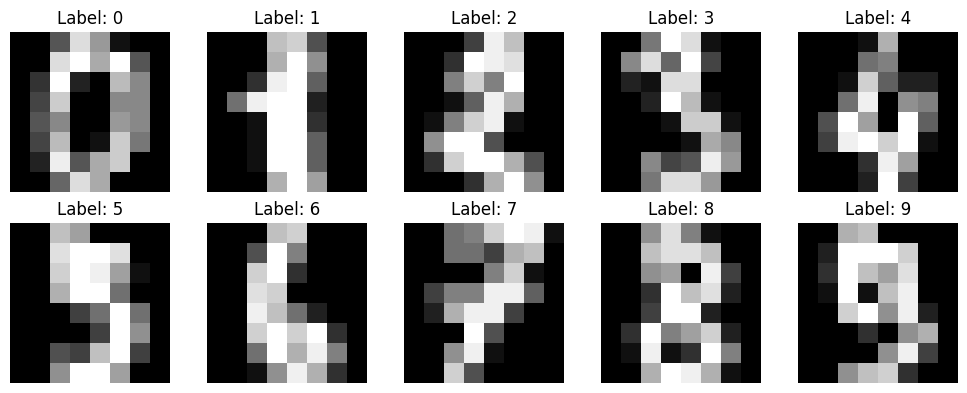

In [ ]:
# データセットを読み込み
digits = load_digits()

print("画像データの形:", digits.images.shape)
print("64次元データの形:", digits.data.shape)
print("正解ラベルの形:", digits.target.shape)

# 最初の10枚を表示
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for index, ax in enumerate(axes.flat):
    ax.imshow(digits.images[index], cmap="gray")
    ax.set_title(f"Label: {digits.target[index]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 演習1. ロジスティック回帰によるモデル構築

ここでは，同種の未知の画像が入力されたとき，その画像がどのクラス(0〜9のいずれ)に分類されるかを出力するモデルを考える．やることは「分類」だが，ここでは0〜9の各数字である確率を10種類予測するという意味で「回帰」と呼んでいることに注意する．

次の「パーツA〜H」を正しく**並び替えて**，モデルとその学習の枠組みを完成させよ．ただし，以下の点に注意すること:
- パーツ自体を変更する必要はありません．
- モデル構築の流れを思い出す．基本的には(1)データの準備，(2)モデルの準備，(3)学習，(4)テスト・推論です．なお，評価データによる評価もしてはいますが，ここではそれによってハイパーパラメータの値が決まるなどはありません．
- **事前に定義していない変数を使うことはできません**．現在の状態でも黄色い線が出ているかもしれませんが，そのままでは未定義の変数を使っているのでエラーが発生します．機械学習に限らずプログラミングの一般事項として，前に定義した変数を後で呼び出す構成になっていなければなりません．
- 選択肢は多いので，各選択肢がどうかではなく，**モデル構築の流れから逆算してどれを入れるべきか**を順次考えるのをお勧めします．回答欄に4つの流れのガイドがありますので参考にしてください．
- コードは難しいかもしれませんが，ここでは**コード自体の意味がわからなくても，緑色のコメントを手がかりに，そのコードが何をしているかがわかる**のが大事です．

### パーツ

セル単位で配置すること

#### A

In [ ]:
# 一時データ40%を、評価用20%とテスト用20%へ分ける
(
    ex1_X_val,
    ex1_X_test,
    ex1_y_val,
    ex1_y_test,
) = train_test_split(
    ex1_X_temp,
    ex1_y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=ex1_y_temp,
)

#### B

In [ ]:
# 前処理とロジスティック回帰をまとめてモデルを用意する
ex1_model = Pipeline([
    # 各特徴量の大きさをそろえる
    ("scaler", StandardScaler()),

    # 多クラス分類を行うロジスティック回帰
    ("classifier", LogisticRegression(
        C=1.0,
        max_iter=2000,
        solver="lbfgs",
    )),
])

#### C

In [ ]:
# 評価データを予測する
ex1_val_predictions = ex1_model.predict(ex1_X_val)

# 評価精度を計算する
ex1_val_accuracy = accuracy_score(
    ex1_y_val,
    ex1_val_predictions,
)

print(f"評価データの精度: {ex1_val_accuracy:.3f}")

#### D

In [ ]:
# 全体を、訓練用60%と一時データ40%へ分ける
(
    ex1_X_train,
    ex1_X_temp,
    ex1_y_train,
    ex1_y_temp,
) = train_test_split(
    ex1_X,
    ex1_y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=ex1_y,
)

#### E

In [ ]:
# テストデータの混同行列を表示し，どの数字をどの数字と間違えたか確認する
ex1_cm = confusion_matrix(
    ex1_y_test,
    ex1_test_predictions,
)

ex1_display = ConfusionMatrixDisplay(
    confusion_matrix=ex1_cm,
    display_labels=np.arange(10),
)

ex1_display.plot()
plt.title("Logistic Regression: Test Confusion Matrix")
plt.show()

#### F

In [ ]:
# Digitsデータセットを読み込む
ex1_digits = load_digits()

# 64個の画素値を入力データとする
ex1_X = ex1_digits.data

# 0〜9の正解ラベルを取り出す
ex1_y = ex1_digits.target

#### G

In [ ]:
# モデルと設定を決めた後にテストデータへ一度だけ予測を行う
ex1_test_predictions = ex1_model.predict(ex1_X_test)

ex1_test_accuracy = accuracy_score(
    ex1_y_test,
    ex1_test_predictions,
)

print(f"テストデータの精度: {ex1_test_accuracy:.3f}")

#### H

In [ ]:
# 訓練データだけを使ってモデルを学習する
# Pipelineを使っているため、StandardScalerも訓練データだけから基準を学習します。
ex1_model.fit(
    ex1_X_train,
    ex1_y_train,
)

### 回答

#### (1) データの準備

まずはデータセットを読み込んで，その後にデータを訓練データ，評価データ，テストデータに分割する必要があります．

In [ ]:
# Digitsデータセットを読み込む
ex1_digits = load_digits()

# 64個の画素値を入力データとする
ex1_X = ex1_digits.data

# 0〜9の正解ラベルを取り出す
ex1_y = ex1_digits.target

In [ ]:
# 全体を、訓練用60%と一時データ40%へ分ける
(
    ex1_X_train,
    ex1_X_temp,
    ex1_y_train,
    ex1_y_temp,
) = train_test_split(
    ex1_X,
    ex1_y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=ex1_y,
)

In [ ]:
# 一時データ40%を、評価用20%とテスト用20%へ分ける
(
    ex1_X_val,
    ex1_X_test,
    ex1_y_val,
    ex1_y_test,
) = train_test_split(
    ex1_X_temp,
    ex1_y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=ex1_y_temp,
)

#### (2) モデルの準備

学習の対象となるモデルを用意します．

In [ ]:
# 前処理とロジスティック回帰をまとめてモデルを用意する
ex1_model = Pipeline([
    # 各特徴量の大きさをそろえる
    ("scaler", StandardScaler()),

    # 多クラス分類を行うロジスティック回帰
    ("classifier", LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver="lbfgs",
    )),
])

#### (3) 学習

これまでに用意したデータに基づいてモデルを学習します．そして，評価データに対する予測をしてみます．

In [ ]:
# 訓練データだけを使ってモデルを学習する
# Pipelineを使っているため、StandardScalerも訓練データだけから基準を学習します。
ex1_model.fit(
    ex1_X_train,
    ex1_y_train,
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
# 評価データを予測する
ex1_val_predictions = ex1_model.predict(ex1_X_val)

# 評価精度を計算する
ex1_val_accuracy = accuracy_score(
    ex1_y_val,
    ex1_val_predictions,
)

print(f"評価データの精度: {ex1_val_accuracy:.3f}")

評価データの精度: 0.967


#### (4) テスト・推論

学習を終えて，テストデータへの評価を行う部分です．

In [ ]:
# モデルと設定を決めた後にテストデータへ一度だけ予測を行う
ex1_test_predictions = ex1_model.predict(ex1_X_test)

ex1_test_accuracy = accuracy_score(
    ex1_y_test,
    ex1_test_predictions,
)

print(f"テストデータの精度: {ex1_test_accuracy:.3f}")

テストデータの精度: 0.964


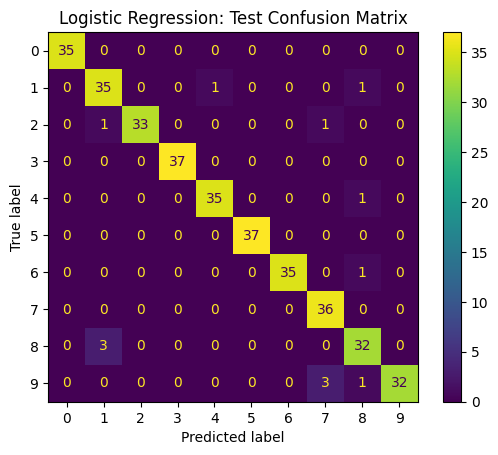

In [ ]:
# テストデータの混同行列を表示し，どの数字をどの数字と間違えたか確認する
ex1_cm = confusion_matrix(
    ex1_y_test,
    ex1_test_predictions,
)

ex1_display = ConfusionMatrixDisplay(
    confusion_matrix=ex1_cm,
    display_labels=np.arange(10),
)

ex1_display.plot()
plt.title("Logistic Regression: Test Confusion Matrix")
plt.show()

## 演習2. パラメータを変更することによる影響を考察する

モデルとして「良いモデル」と「悪いモデル」があるが，一般に「良いモデル」とは「未知のデータに対しても良い結果を出せるモデル」である．様々な考え方があるが，ここでは「より多くのデータに対して，正解のクラスを正しく予測できること」を「良い結果」として定義する．

モデルを「良いモデル」とするためには，学習データが学習されるに適している状態であるだけでなく，モデルにおける予測を制御する**ハイパーパラメータ**の適切な設定が非常に重要である．そこで，そのような**ハイパーパラメータの最適値の簡易的な探索**を行ってみよう．

ロジスティック回帰に基づくモデルでは，`C`というハイパーパラメータ(逆正則化パラメータ)がある．この`C`はモデルをどの程度単純に保つかに関係している:
- `C`が小さい場合: モデルに対する制限(正則化)が強まり，学習が不足してしまう**未学習**の状態になりやすい．
- `C`が大きい場合: モデルに対する制限が弱いので，訓練データに影響されやすく，学習データに対して正しい結果を出せるがテストデータに対して間違えやすくなる**過学習**の状態になりやすい．

ここでは`C`として次の値を比較してみよう．このようにルールベースで値を定めてその範囲内で最適な値を探ろうとするのをグリッドサーチという．

```python
[0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
```

なお，ハイパーパラメータの最適値の探索として，Optunaと呼ばれるライブラリを使ったベイズ最適化などの統計的手法もあるが，ここでは紹介しない．また，比較では評価データを使用し，テストデータは最後まで使用しない．

### 演習2.1. 考察用のコード構築

演習1と同様に，`c`の値を変えて繰り返し行う学習部分について，以下のパーツA〜Fを並び替えて，動作するように配置せよ．ただし，以下の点に注意すること

- パーツ自体を変更する必要はありません．
- 回答スペースの指示に合わせること．例えば「比較するCの候補」と「各設定の結果を保存するリスト」は変更せず，`for c_value in candidate_c_values:`以下のみが変更対象
- Pythonの一般的事項として，繰り返しのインデントに注意すること
- ここでは演習1とは違ってパーツごとにセルの入れ場所がないので，自分で考えつつ回答スペースに並べていくこと．

#### パーツ

##### A

In [ ]:
# train,valそれぞれの分類精度を計算
train_accuracy = accuracy_score(
    ex1_y_train,
    train_predictions,
)

val_accuracy = accuracy_score(
    ex1_y_val,
    val_predictions,
)

##### B

In [ ]:
# そのCの時の結果を記録しておく
c_results.append({
    "C": c_value,
    "train_accuracy": train_accuracy,
    "val_accuracy": val_accuracy,
})

# そのCの時の結果をログに出力する
print(
    f"C={c_value:7.3f} | "
    f"train={train_accuracy:.3f} | "
    f"val={val_accuracy:.3f}"
)

##### C

In [ ]:
# 訓練データだけで学習する
model.fit(
    ex1_X_train,
    ex1_y_train,
)

##### D

In [ ]:
# 訓練データと評価データを予測
train_predictions = model.predict(ex1_X_train)
val_predictions = model.predict(ex1_X_val)

##### E

In [ ]:
# Cだけを変更し、そのほかは同じ設定にする
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=c_value,
        max_iter=2000,
        solver="lbfgs",
    )),
])

#### 回答

コメントの指示通りに並べること

In [ ]:
# 比較するCの候補
candidate_c_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
    10000.0
]

# 各設定の結果を保存するリスト
c_results = []

for c_value in candidate_c_values:
    # Cだけを変更し、そのほかは同じ設定にする
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            C=c_value,
            max_iter=2000,
            solver="lbfgs",
        )),
    ])

    # 訓練データだけで学習する
    model.fit(
        ex1_X_train,
        ex1_y_train,
    )

    # 訓練データと評価データを予測
    train_predictions = model.predict(ex1_X_train)
    val_predictions = model.predict(ex1_X_val)

    # train,valそれぞれの分類精度を計算
    train_accuracy = accuracy_score(
        ex1_y_train,
        train_predictions,
    )

    val_accuracy = accuracy_score(
        ex1_y_val,
        val_predictions,
    )

    # そのCの時の結果を記録しておく
    c_results.append({
        "C": c_value,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
    })

    # そのCの時の結果をログに出力する
    print(
        f"C={c_value:7.3f} | "
        f"train={train_accuracy:.3f} | "
        f"val={val_accuracy:.3f}"
    )

c_results_df = pd.DataFrame(c_results)

c_results_df

C=  0.001 | train=0.916 | val=0.891
C=  0.010 | train=0.955 | val=0.944
C=  0.100 | train=0.989 | val=0.961
C=  1.000 | train=1.000 | val=0.967
C= 10.000 | train=1.000 | val=0.967
C=100.000 | train=1.000 | val=0.969
C=1000.000 | train=1.000 | val=0.969
C=10000.000 | train=1.000 | val=0.969


,C,train_accuracy,val_accuracy
0,0.001,0.915584,0.891365
1,0.010,0.955473,0.944290
2,0.100,0.988868,0.961003
3,1.000,1.000000,0.966574
4,10.000,1.000000,0.966574
5,100.000,1.000000,0.969359
6,1000.000,1.000000,0.969359
7,10000.000,1.000000,0.969359


### 演習2.2. 結果から考察する

以下のコードでは，演習2.1で実験した結果として，`C`ごとの訓練データに対する精度と評価データに対する精度をプロットとして可視化している．

まず，以下のコードを実行せよ．

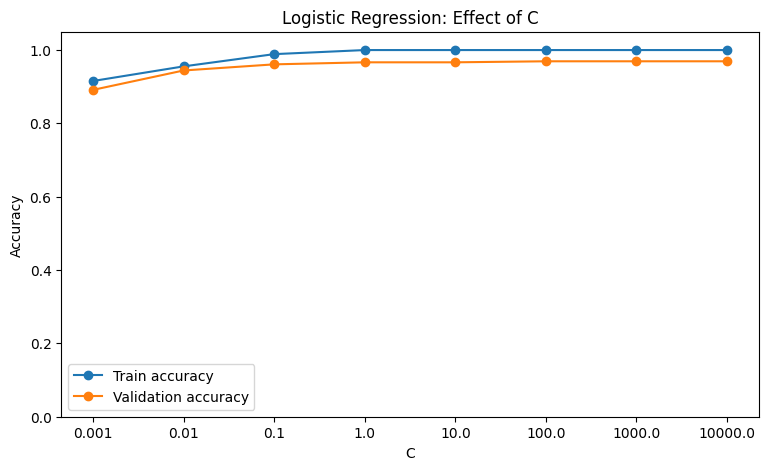

In [ ]:
# Cごとの訓練精度と評価精度を表示する
x_positions = np.arange(len(c_results_df))

plt.figure(figsize=(9, 5))

plt.plot(
    x_positions,
    c_results_df["train_accuracy"],
    marker="o",
    label="Train accuracy",
)

plt.plot(
    x_positions,
    c_results_df["val_accuracy"],
    marker="o",
    label="Validation accuracy",
)

plt.xticks(
    x_positions,
    c_results_df["C"].astype(str),
)

plt.ylim(0.0, 1.05)
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Effect of C")
plt.legend()
plt.show()

得られた結果から以下の点を考察せよ．

1. `C`の値と訓練精度，評価精度との間にどのような関係があるか．
2. このモデルの評価精度をより高めるために，別にできることはあるか．ウェブ検索等を併用して良い．
3. そのほかの考察

【模範解答】
1. `C`の値が大きくなるほど，訓練制度も評価精度も上がる傾向にある．
2. 元々精度が高いので，完全な正解を目指す場合は元のデータに対する前処理を検討する．

### 演習2.3 評価データに対して最適な`C`を用いてテストデータに対する予測を行う

演習2.2において，評価データに対して指定した範囲内で最適な`C`が得られる．その値を用いて，最終的なテストデータに対する予測を行い，精度を確認してみる．

以下のコード内には`# [WRITE ME n]`とされている箇所が複数存在する(ただし`n`には番号が入る)．そ先ほど行った**演習1の結果**を参考にして，その箇所をそれぞれ適切に埋めて実行せよ．なお，演習1と一字一句同じではないが，同様のコードが入ることを想定している．

In [ ]:
# 評価精度が最大の行番号を取得する
best_c_index = c_results_df["val_accuracy"].idxmax()

# 最良のCと、そのときの評価精度を取り出す
best_c = float(
    c_results_df.loc[best_c_index, "C"]
)

best_c_val_accuracy = float(
    c_results_df.loc[best_c_index, "val_accuracy"]
)

print("評価データで選ばれたC:", best_c)
print(f"そのときの評価精度: {best_c_val_accuracy:.3f}")

評価データで選ばれたC: 100.0
そのときの評価精度: 0.969


In [ ]:
# 評価データで選んだCを使ってモデルを作る
selected_logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C = best_c,
        max_iter=1000,
        solver="lbfgs",
    )),
])

# ここでは訓練データだけで学習する
selected_logreg_model.fit(
    ex1_X_train,
    ex1_y_train,
)

# テストデータを予測する
selected_logreg_test_predictions = (
    selected_logreg_model.predict(ex1_X_test)
)

# 精度の評価
selected_logreg_test_accuracy = accuracy_score(
    ex1_y_test,
    selected_logreg_test_predictions,
)

print(
    f"選択したロジスティック回帰のテスト精度: "
    f"{selected_logreg_test_accuracy:.3f}"
)

選択したロジスティック回帰のテスト精度: 0.956


## 演習3. (発展編) PyTorchと深層学習による同様の分類の実装

この演習は，これまでの内容で物足りずに深層学習をある程度知っている人向けの内容となる．

演習1,2ではScikit-learnに備わっているロジスティック回帰を利用したが，ここでは深層学習の手法に基づいて同様の分類(クラス予測)を行い，ロジスティック回帰によって分類を行った場合の結果と比較してみる．

### 演習3.1. モデルの構築

以下の「パーツA〜J」を適切に**並び替えて**，モデルとその学習の枠組みを完成させよ．ここでは丁寧な誘導を最初から与えていないが，**演習1で行った流れと説明を再度思い出す**こと．

#### パーツ

##### A

In [ ]:
# ニューラルネットワークの設計図
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)

##### B

In [ ]:
# NumPy配列をTensorへ変換し，Datasetを作る
deep_train_dataset = TensorDataset(
    torch.tensor(deep_X_train),
    torch.tensor(deep_y_train),
)

deep_val_dataset = TensorDataset(
    torch.tensor(deep_X_val),
    torch.tensor(deep_y_val),
)

deep_test_dataset = TensorDataset(
    torch.tensor(deep_X_test),
    torch.tensor(deep_y_test),
)

# DataLoaderでデータを小さなまとまりに分ける
deep_train_loader = DataLoader(
    deep_train_dataset,
    batch_size=64,
    shuffle=True,
)

deep_val_loader = DataLoader(
    deep_val_dataset,
    batch_size=128,
    shuffle=False,
)

deep_test_loader = DataLoader(
    deep_test_dataset,
    batch_size=128,
    shuffle=False,
)

##### C

In [ ]:
def evaluate_deep_model(model, data_loader):
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)

            outputs = model(features)
            batch_predictions = outputs.argmax(dim=1)

            predictions.extend(
                batch_predictions.cpu().numpy()
            )
            true_labels.extend(labels.numpy())

    accuracy = accuracy_score(
        true_labels,
        predictions,
    )

    return accuracy, predictions, true_labels

##### D

In [ ]:
deep_model = DigitNet().to(device)

deep_loss_function = nn.CrossEntropyLoss()

deep_optimizer = torch.optim.Adam(
    deep_model.parameters(),
    lr=0.001,
)

##### E

In [ ]:
# scikit-learnと同じ分割を使う
# ニューラルネットワーク向けに0〜1へ正規化
deep_X_train = ex1_X_train.astype(np.float32) / 16.0
deep_X_val = ex1_X_val.astype(np.float32) / 16.0
deep_X_test = ex1_X_test.astype(np.float32) / 16.0

# CrossEntropyLossで扱える整数型へ変換
deep_y_train = ex1_y_train.astype(np.int64)
deep_y_val = ex1_y_val.astype(np.int64)
deep_y_test = ex1_y_test.astype(np.int64)

##### F

In [ ]:
best_val_accuracy = -1.0
best_epoch = None

deep_train_loss_history = []
deep_val_accuracy_history = []

for epoch in range(50):
    deep_model.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in deep_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        deep_optimizer.zero_grad()

        outputs = deep_model(features)
        loss = deep_loss_function(outputs, labels)

        loss.backward()
        deep_optimizer.step()

        total_loss += loss.item() * features.size(0)
        total_count += labels.size(0)

    average_loss = total_loss / total_count
    deep_train_loss_history.append(average_loss)

    val_accuracy, _, _ = evaluate_deep_model(
        deep_model,
        deep_val_loader,
    )

    deep_val_accuracy_history.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

##### G

In [ ]:
(
    deep_test_accuracy,
    deep_test_predictions,
    deep_test_true_labels,
) = evaluate_deep_model(
    final_deep_model,
    deep_test_loader,
)

print("評価データで選ばれたエポック数:", best_epoch)
print(f"最良の評価精度: {best_val_accuracy:.3f}")
print(
    f"深層学習モデルのテスト精度: "
    f"{deep_test_accuracy:.3f}"
)

##### H

In [ ]:
final_deep_model = DigitNet().to(device)

final_deep_optimizer = torch.optim.Adam(
    final_deep_model.parameters(),
    lr=0.001,
)

for epoch in range(best_epoch):
    final_deep_model.train()

    for features, labels in deep_train_val_loader:
        features = features.to(device)
        labels = labels.to(device)

        final_deep_optimizer.zero_grad()

        outputs = final_deep_model(features)
        loss = deep_loss_function(outputs, labels)

        loss.backward()
        final_deep_optimizer.step()

##### I

In [ ]:
comparison_df = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "PyTorch Neural Network",
    ],
    "test_accuracy": [
        selected_logreg_test_accuracy,
        deep_test_accuracy,
    ],
})

display(comparison_df)

plt.figure(figsize=(7, 4))
plt.bar(
    comparison_df["model"],
    comparison_df["test_accuracy"],
)
plt.ylim(0.0, 1.0)
plt.ylabel("Test accuracy")
plt.title("Logistic Regression vs Neural Network")
plt.xticks(rotation=15)
plt.show()

##### J

In [ ]:
deep_X_train_val = np.concatenate(
    [deep_X_train, deep_X_val],
    axis=0,
)

deep_y_train_val = np.concatenate(
    [deep_y_train, deep_y_val],
    axis=0,
)

deep_train_val_dataset = TensorDataset(
    torch.tensor(deep_X_train_val),
    torch.tensor(deep_y_train_val),
)

deep_train_val_loader = DataLoader(
    deep_train_val_dataset,
    batch_size=64,
    shuffle=True,
)

#### 回答

In [ ]:
# scikit-learnと同じ分割を使う
# ニューラルネットワーク向けに0〜1へ正規化
deep_X_train = ex1_X_train.astype(np.float32) / 16.0
deep_X_val = ex1_X_val.astype(np.float32) / 16.0
deep_X_test = ex1_X_test.astype(np.float32) / 16.0

# CrossEntropyLossで扱える整数型へ変換
deep_y_train = ex1_y_train.astype(np.int64)
deep_y_val = ex1_y_val.astype(np.int64)
deep_y_test = ex1_y_test.astype(np.int64)

In [ ]:
# NumPy配列をTensorへ変換し，Datasetを作る
deep_train_dataset = TensorDataset(
    torch.tensor(deep_X_train),
    torch.tensor(deep_y_train),
)

deep_val_dataset = TensorDataset(
    torch.tensor(deep_X_val),
    torch.tensor(deep_y_val),
)

deep_test_dataset = TensorDataset(
    torch.tensor(deep_X_test),
    torch.tensor(deep_y_test),
)

# DataLoaderでデータを小さなまとまりに分ける
deep_train_loader = DataLoader(
    deep_train_dataset,
    batch_size=64,
    shuffle=True,
)

deep_val_loader = DataLoader(
    deep_val_dataset,
    batch_size=128,
    shuffle=False,
)

deep_test_loader = DataLoader(
    deep_test_dataset,
    batch_size=128,
    shuffle=False,
)

In [ ]:
# ニューラルネットワークの設計図
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
deep_model = DigitNet().to(device)

deep_loss_function = nn.CrossEntropyLoss()

deep_optimizer = torch.optim.Adam(
    deep_model.parameters(),
    lr=0.001,
)

In [ ]:
def evaluate_deep_model(model, data_loader):
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)

            outputs = model(features)
            batch_predictions = outputs.argmax(dim=1)

            predictions.extend(
                batch_predictions.cpu().numpy()
            )
            true_labels.extend(labels.numpy())

    accuracy = accuracy_score(
        true_labels,
        predictions,
    )

    return accuracy, predictions, true_labels

In [ ]:
best_val_accuracy = -1.0
best_epoch = None

deep_train_loss_history = []
deep_val_accuracy_history = []

for epoch in range(50):
    deep_model.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in deep_train_loader:
        features = features.to(device)
        labels = labels.to(device)

        deep_optimizer.zero_grad()

        outputs = deep_model(features)
        loss = deep_loss_function(outputs, labels)

        loss.backward()
        deep_optimizer.step()

        total_loss += loss.item() * features.size(0)
        total_count += labels.size(0)

    average_loss = total_loss / total_count
    deep_train_loss_history.append(average_loss)

    val_accuracy, _, _ = evaluate_deep_model(
        deep_model,
        deep_val_loader,
    )

    deep_val_accuracy_history.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

In [ ]:
deep_X_train_val = np.concatenate(
    [deep_X_train, deep_X_val],
    axis=0,
)

deep_y_train_val = np.concatenate(
    [deep_y_train, deep_y_val],
    axis=0,
)

deep_train_val_dataset = TensorDataset(
    torch.tensor(deep_X_train_val),
    torch.tensor(deep_y_train_val),
)

deep_train_val_loader = DataLoader(
    deep_train_val_dataset,
    batch_size=64,
    shuffle=True,
)

In [ ]:
final_deep_model = DigitNet().to(device)

final_deep_optimizer = torch.optim.Adam(
    final_deep_model.parameters(),
    lr=0.001,
)

for epoch in range(best_epoch):
    final_deep_model.train()

    for features, labels in deep_train_val_loader:
        features = features.to(device)
        labels = labels.to(device)

        final_deep_optimizer.zero_grad()

        outputs = final_deep_model(features)
        loss = deep_loss_function(outputs, labels)

        loss.backward()
        final_deep_optimizer.step()

In [ ]:
(
    deep_test_accuracy,
    deep_test_predictions,
    deep_test_true_labels,
) = evaluate_deep_model(
    final_deep_model,
    deep_test_loader,
)

print("評価データで選ばれたエポック数:", best_epoch)
print(f"最良の評価精度: {best_val_accuracy:.3f}")
print(
    f"深層学習モデルのテスト精度: "
    f"{deep_test_accuracy:.3f}"
)

評価データで選ばれたエポック数: 28
最良の評価精度: 0.972
深層学習モデルのテスト精度: 0.978


,model,test_accuracy
0,Logistic Regression,0.955556
1,PyTorch Neural Network,0.977778


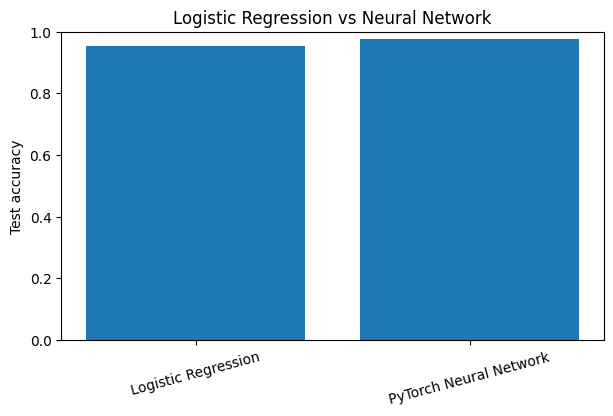

In [ ]:
comparison_df = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "PyTorch Neural Network",
    ],
    "test_accuracy": [
        selected_logreg_test_accuracy,
        deep_test_accuracy,
    ],
})

display(comparison_df)

plt.figure(figsize=(7, 4))
plt.bar(
    comparison_df["model"],
    comparison_df["test_accuracy"],
)
plt.ylim(0.0, 1.0)
plt.ylabel("Test accuracy")
plt.title("Logistic Regression vs Neural Network")
plt.xticks(rotation=15)
plt.show()

### 演習4.2. 比較結果からの考察

ロジスティック回帰による分類と，深層学習のモデルに基づく分類を比較し，どちらの精度が高かったかを確認せよ．

また，深層学習のモデルに基づく分類の精度がより高かったとしても「ロジスティック回帰に比べて深層学習が絶対的に優れている」と断定できない理由を説明せよ．

【模範解答】

深層学習のモデルの精度が微妙に高かった．しかし，モデルの精度はロジスティック回帰側のモデルの学習設定に依存する他，元のデータに対する前処理の有無等にも影響を受けるため，一概に深層学習が優れていると断定することはできない．